In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("Students_Results.csv")

In [21]:
df.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  object 
 2   EthnicGroup          28801 non-null  object 
 3   ParentEduc           28796 non-null  object 
 4   LunchType            30641 non-null  object 
 5   TestPrep             28811 non-null  object 
 6   ParentMaritalStatus  29451 non-null  object 
 7   PracticeSport        30010 non-null  object 
 8   IsFirstChild         29737 non-null  object 
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  object 
 11  WklyStudyHours       29686 non-null  object 
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), object(10)


In [8]:
df.describe()

,Unnamed: 0,NrSiblings,MathScore,ReadingScore,WritingScore
count,30641.000000,29069.000000,30641.000000,30641.000000,30641.000000
mean,499.556607,2.145894,66.558402,69.377533,68.418622
std,288.747894,1.458242,15.361616,14.758952,15.443525
min,0.000000,0.000000,0.000000,10.000000,4.000000
25%,249.000000,1.000000,56.000000,59.000000,58.000000
50%,500.000000,2.000000,67.000000,70.000000,69.000000
75%,750.000000,3.000000,78.000000,80.000000,79.000000
max,999.000000,7.000000,100.000000,100.000000,100.000000


In [9]:
df.columns

Index(['Unnamed: 0', 'Gender', 'EthnicGroup', 'ParentEduc', 'LunchType',
       'TestPrep', 'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild',
       'NrSiblings', 'TransportMeans', 'WklyStudyHours', 'MathScore',
       'ReadingScore', 'WritingScore'],
      dtype='object')

In [10]:
df.isna().sum()

,0
Unnamed: 0,0
Gender,0
EthnicGroup,1840
ParentEduc,1845
LunchType,0
TestPrep,1830
ParentMaritalStatus,1190
PracticeSport,631
IsFirstChild,904
NrSiblings,1572


In [87]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df.drop("Unnamed: 0" , axis=1)

In [16]:
cols = ['Gender', 'EthnicGroup', 'ParentEduc', 'LunchType',
       'TestPrep', 'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild' , 'TransportMeans', 'WklyStudyHours']

In [18]:
for i in cols:
  # print(i)
  print(df[i].value_counts())

Gender
female    15424
male      15217
Name: count, dtype: int64
EthnicGroup
group C    9212
group D    7503
group B    5826
group E    4041
group A    2219
Name: count, dtype: int64
ParentEduc
some college          6633
high school           5687
associate's degree    5550
some high school      5517
bachelor's degree     3386
master's degree       2023
Name: count, dtype: int64
LunchType
standard        19905
free/reduced    10736
Name: count, dtype: int64
TestPrep
none         18856
completed     9955
Name: count, dtype: int64
ParentMaritalStatus
married     16844
single       7097
divorced     4919
widowed       591
Name: count, dtype: int64
PracticeSport
sometimes    15213
regularly    10793
never         4004
Name: count, dtype: int64
IsFirstChild
yes    19082
no     10655
Name: count, dtype: int64
TransportMeans
school_bus    16145
private       11362
Name: count, dtype: int64
WklyStudyHours
5 - 10    16246
< 5        8238
> 10       5202
Name: count, dtype: int64


In [ ]:
df['TotalScore'] = df['MathScore'] + df['ReadingScore'] + df['WritingScore']

# we don't want to fill na because we have no missing values on target feature

###Start Analysis

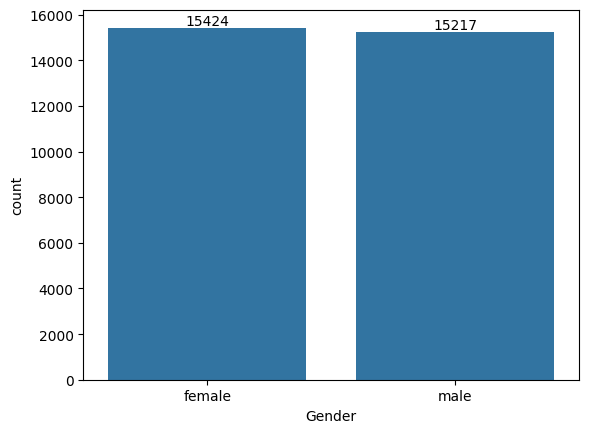

In [31]:
from matplotlib import container
# Gender Distribution

ax = sns.countplot(data=df , x='Gender')
# how to show the labels
ax.bar_label(ax.containers[0])
plt.show()

# Numbers of Female are greater then male

In [35]:
df.columns

Index(['Gender', 'EthnicGroup', 'ParentEduc', 'LunchType', 'TestPrep',
       'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild', 'NrSiblings',
       'TransportMeans', 'WklyStudyHours', 'MathScore', 'ReadingScore',
       'WritingScore'],
      dtype='object')

In [42]:
gb = df.groupby("ParentEduc")[['MathScore' , "ReadingScore" , "WritingScore" ]].mean()

In [43]:
gb

,MathScore,ReadingScore,WritingScore
ParentEduc,,,
associate's degree,68.365586,71.124324,70.299099
bachelor's degree,70.466627,73.062020,73.331069
high school,64.435731,67.213997,65.421136
master's degree,72.336134,75.832921,76.356896
some college,66.390472,69.179708,68.501432
some high school,62.584013,65.510785,63.632409


In [44]:
df.groupby("EthnicGroup").agg({"MathScore":'mean' , "ReadingScore":'mean' , "WritingScore":'mean'})

,MathScore,ReadingScore,WritingScore
EthnicGroup,,,
group A,62.991888,66.787742,65.251915
group B,63.490216,67.320460,65.895125
group C,64.695723,68.438233,66.999240
group D,67.666400,70.382247,70.890844
group E,75.298936,74.251423,72.677060


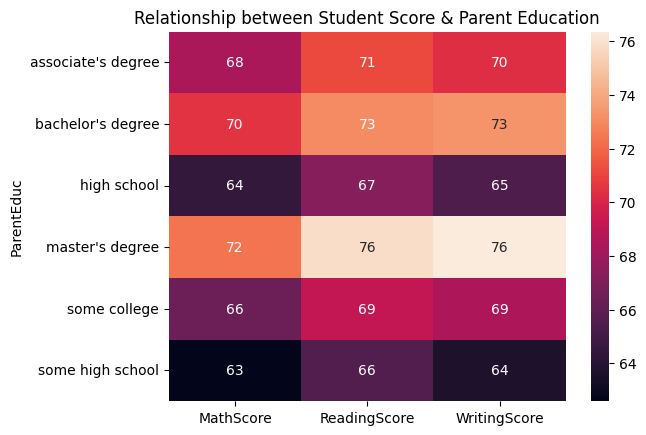

In [53]:
sns.heatmap(gb , annot=True)
plt.title("Relationship between Student Score & Parent Education")
plt.show()

# From the preview chart we have calculated that the education of the parents have good impect on their score


In [48]:
gb2 = df.groupby('ParentMaritalStatus')[['MathScore' , "ReadingScore" , "WritingScore" ]].mean()

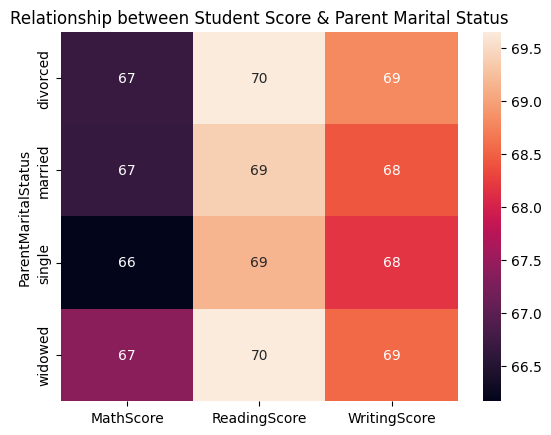

In [52]:
sns.heatmap(gb2 , annot=True)
plt.title("Relationship between Student Score & Parent Marital Status")
plt.show()

##There are no impect of parents marital status on their score

In [55]:
df.columns

Index(['Gender', 'EthnicGroup', 'ParentEduc', 'LunchType', 'TestPrep',
       'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild', 'NrSiblings',
       'TransportMeans', 'WklyStudyHours', 'MathScore', 'ReadingScore',
       'WritingScore'],
      dtype='object')

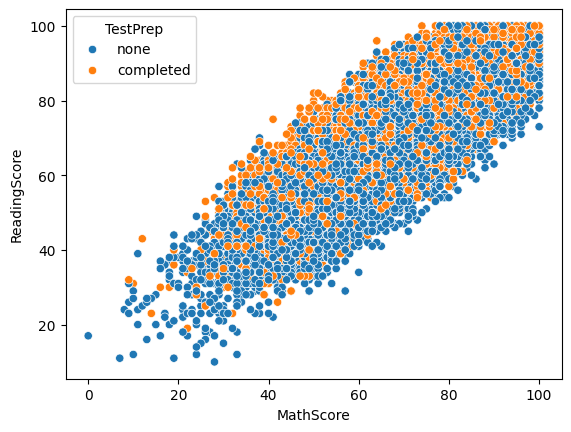

In [59]:
sns.scatterplot(data=df , x='MathScore' , y='ReadingScore' , hue='TestPrep')
plt.show()
#

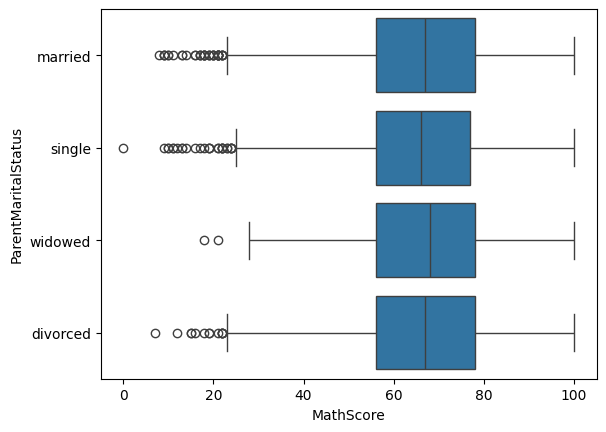

In [64]:
sns.boxplot(data=df , x='MathScore' , y='ParentMaritalStatus')
plt.show()

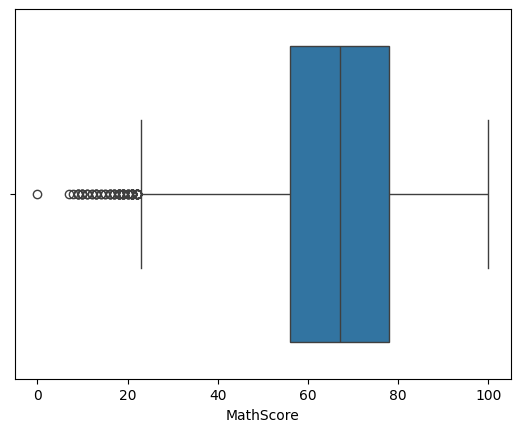

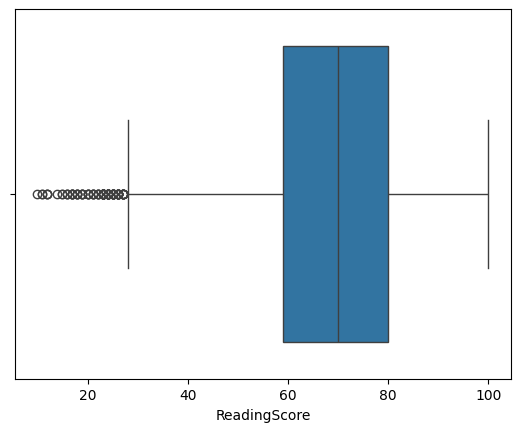

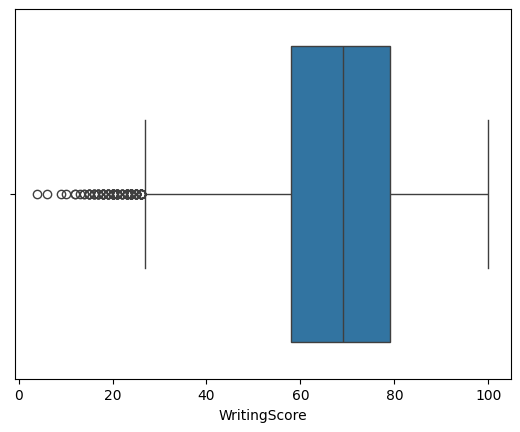

In [75]:


sns.boxplot(data=df , x='MathScore')
plt.show()
sns.boxplot(data=df , x='ReadingScore')
plt.show()
sns.boxplot(data=df , x='WritingScore')
plt.show()

## In Math Subject Avg lower then other subjects

## There are so many outliers
in these feature 'MathScore', 'ReadingScore',
       'WritingScore'

In [76]:
df.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


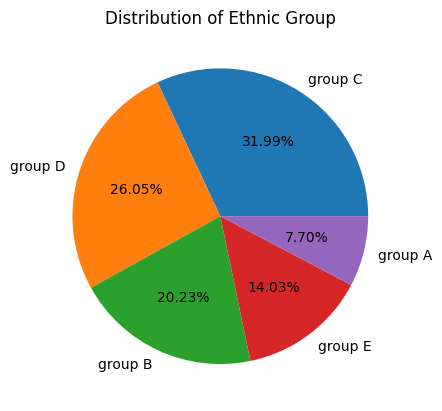

In [86]:
pi = df['EthnicGroup'].value_counts()

plt.pie(pi , labels=pi.index , autopct='%1.2f%%' )
plt.title("Distribution of Ethnic Group")
plt.show()

<Axes: xlabel='MathScore', ylabel='Count'>

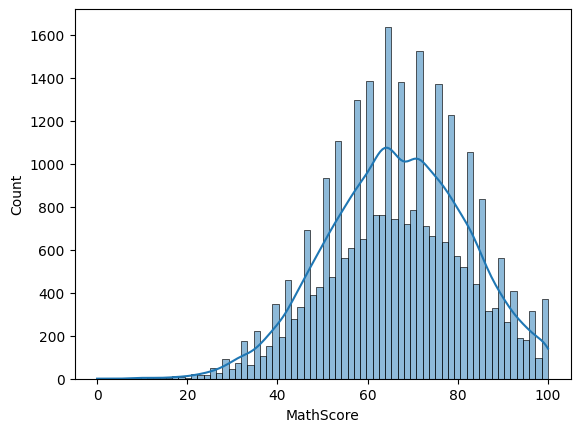

In [92]:
sns.histplot(df['MathScore'], kde=True)

# Math Score Distrubution are Left skewed


<Axes: xlabel='Gender', ylabel='MathScore'>

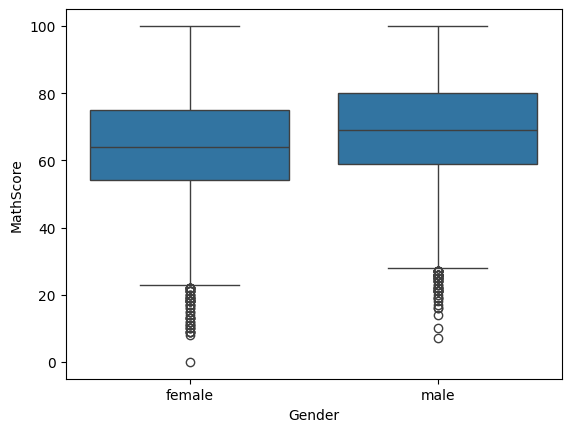

In [93]:
sns.boxplot(x='Gender', y='MathScore', data=df)

# MAlE are perfoming Good

<Axes: xlabel='WklyStudyHours', ylabel='MathScore'>

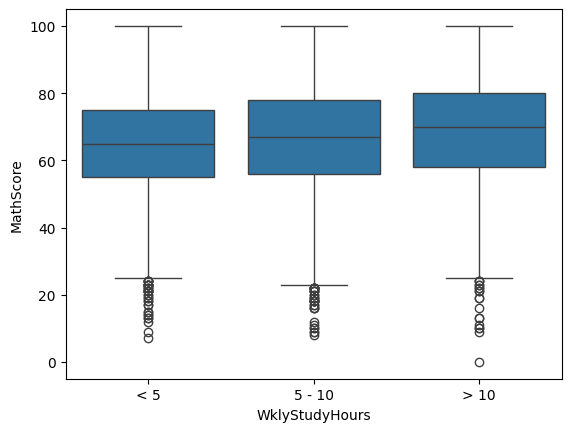

In [99]:
sns.boxplot(x='WklyStudyHours', y='MathScore', data=df)

# There are clear difference between study hours
# which students study more are good in Math marks

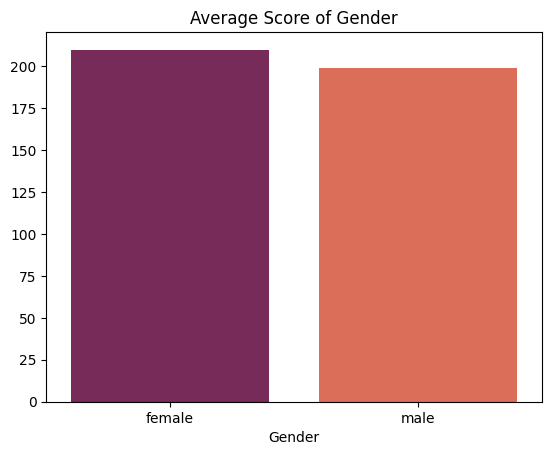

In [152]:
av = df.groupby('Gender')['TotalScore'].mean()

sns.barplot(y=av.values , x=av.index , palette='rocket' , legend=True)
plt.title("Average Score of Gender")


# plt.show()
plt.savefig("Average Score Gender Wise")

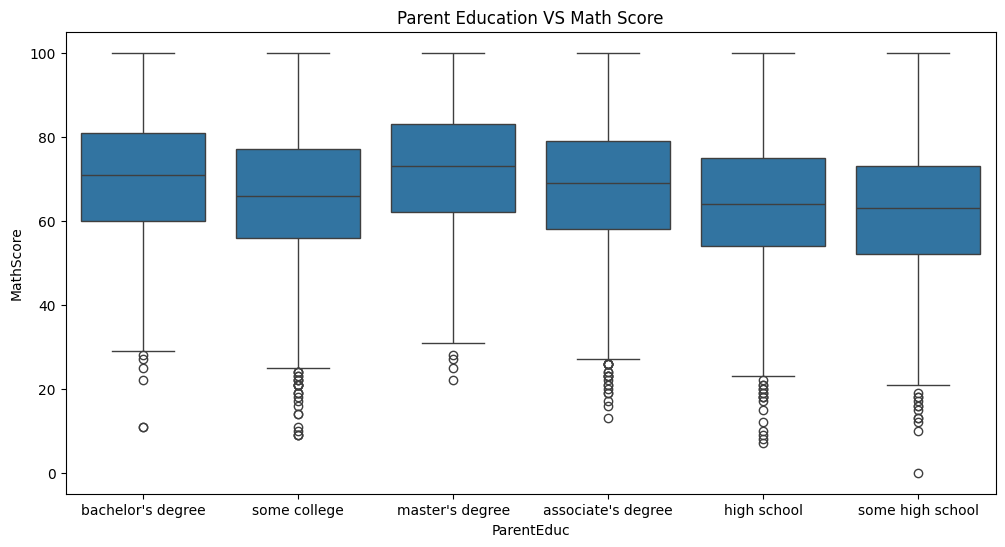

In [150]:
plt.figure(figsize=(12,6))
sns.boxplot(x='ParentEduc' , y='MathScore' , data=df)
plt.title("Parent Education VS Math Score")
# plt.show()


plt.savefig("PrentsEDU_MathMarks.png")

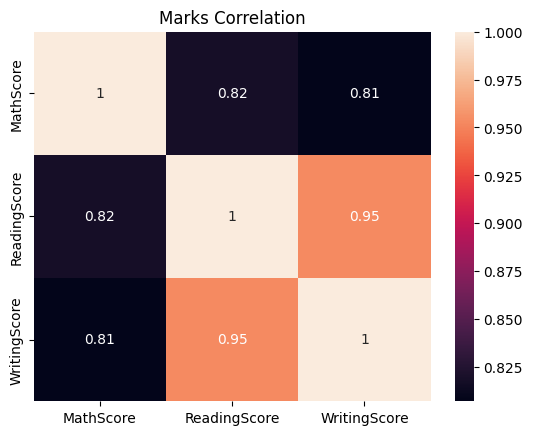

In [153]:
marks = ['MathScore' , 'ReadingScore' , 'WritingScore']

sns.heatmap(df[marks].corr() , annot=True)
plt.title("Marks Correlation")

plt.savefig("MarksCorrelation.png", dpi=300)


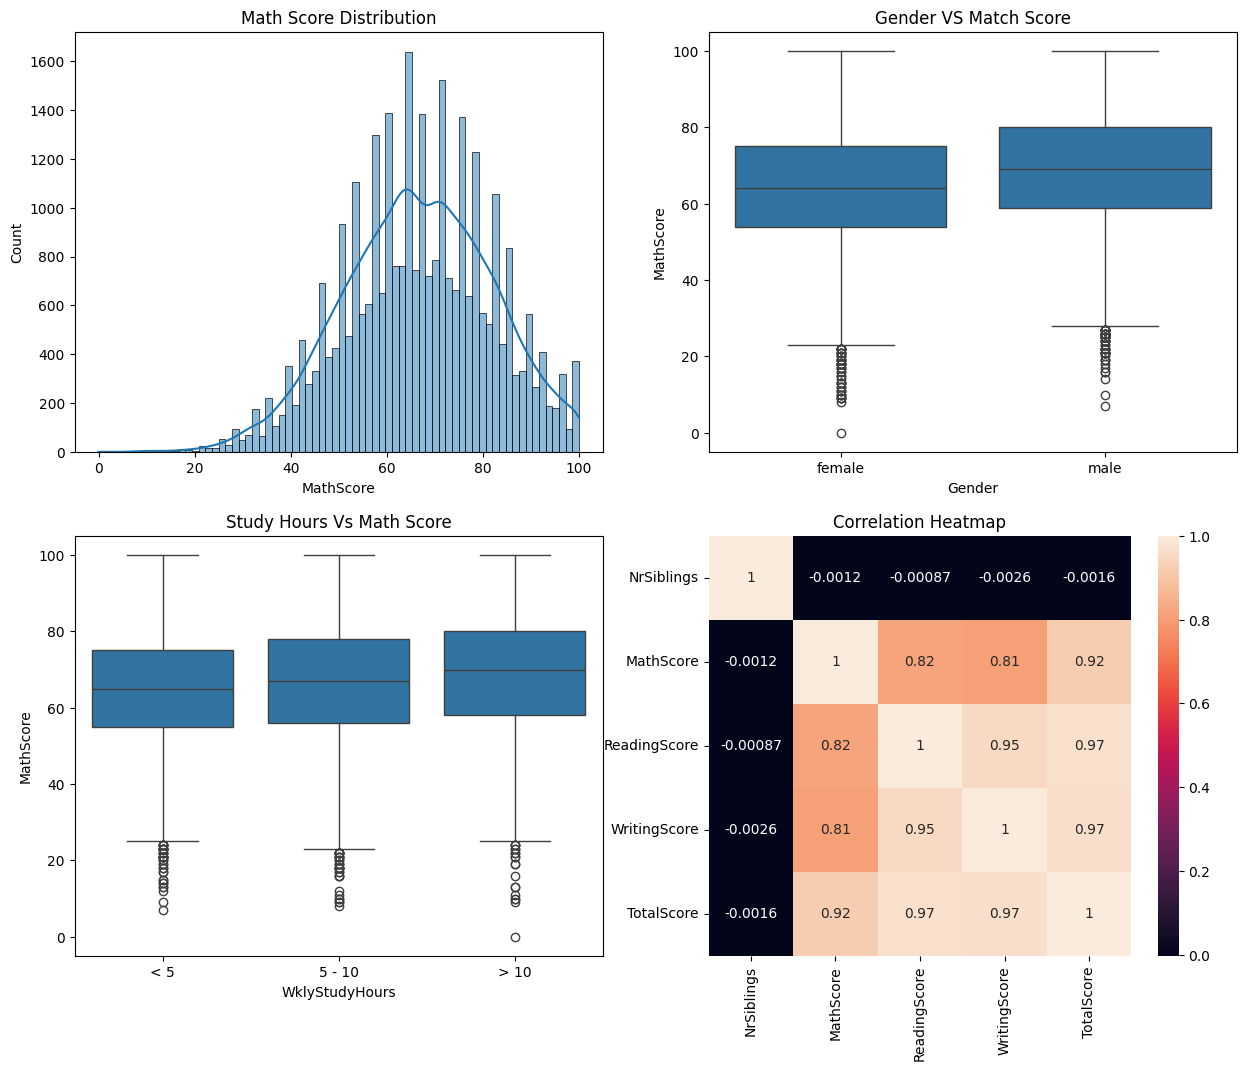

In [149]:
	# MathScore Distribution
	# •	Gender vs Score
	# •	Study Hours vs Score
	# •	Correlation Heatmap



plt.figure(figsize=(15,12))

plt.subplot(2,2,1)
sns.histplot(df['MathScore'], kde=True)
plt.title("Math Score Distribution")

plt.subplot(2,2,2)
sns.boxplot(x='Gender' , y='MathScore' , data=df)
plt.title("Gender VS Match Score")

plt.subplot(2,2,3)
sns.boxplot(x='WklyStudyHours', y='MathScore', data=df)
plt.title("Study Hours Vs Math Score")

plt.subplot(2,2,4)
sns.heatmap(df.corr(numeric_only=True) , annot=True)
plt.title("Correlation Heatmap")

# plt.show()

plt.savefig("Distribution.png")

##Key Insights

Students with higher study hours tend to perform better

Strong correlation between all academic scores

Parental education influences student performance

Some outliers exist in score distribution